# Lab 4: Improving and Comparing Machine Learning Models
### Telco Customer Churn - Decision Tree vs Random Forest, Cross-Validation, Hyperparameter Tuning

**Name:** Teesha kumari   
**Student ID:** 023-23-0195  
**Dataset:** Telco Customer Churn (same dataset used in Labs 2 & 3)

.

## Setup - Imports and Data Loading



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.shape

(7043, 21)

## Part 0 - Re-cleaning (same as Lab 2)


In [ ]:
df = df.drop(columns=["customerID"])

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())


y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn"])

X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("Churn rate:", y.mean().round(3))

X shape: (7043, 30)
Churn rate: 0.265


---
## Part 1 - Decision Tree Baseline Review



### Task 1 - Recreate the train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((5634, 30), (1409, 30))

### Task 2 - Retrain the Lab 3 Decision Tree and report its metrics



In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print(f"Decision Tree  ->  Accuracy: {dt_acc:.3f} | Precision: {dt_prec:.3f} | Recall: {dt_rec:.3f} | F1: {dt_f1:.3f}")

Decision Tree  ->  Accuracy: 0.794 | Precision: 0.630 | Recall: 0.545 | F1: 0.585


---
## Part 2 - Random Forest


### Task 3 - Train a Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest trained with", rf_model.n_estimators, "trees.")

Random Forest trained with 200 trees.


### Task 4 - Why might a Random Forest generalize better than a single unrestricted Decision Tree?

A single unrestricted Decision Tree tries to fit the training data perfectly, which means it ends up learning noise and outliers along with the real patterns  this is overfitting. A Random Forest builds many different trees, each trained on a random bootstrapped sample of the data and considering only a random subset of features at each split, then averages their predictions (majority vote for classification). Because each tree's individual errors are somewhat independent, averaging over many trees cancels out a lot of that noise, which reduces variance without increasing bias  so the ensemble generalizes better to unseen data than any single deep tree would.



---
## Part 3 - Evaluation & Comparison


### Task 5 - Random Forest metrics + confusion matrix

Random Forest  ->  Accuracy: 0.790 | Precision: 0.634 | Recall: 0.495 | F1: 0.556


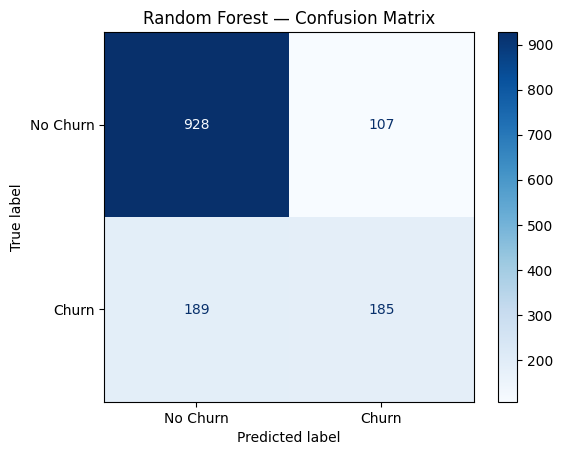

In [ ]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Random Forest  ->  Accuracy: {rf_acc:.3f} | Precision: {rf_prec:.3f} | Recall: {rf_rec:.3f} | F1: {rf_f1:.3f}")

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.show()

### Task 6 - Comparison table: Decision Tree vs Random Forest

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_acc, rf_acc],
    "Precision": [dt_prec, rf_prec],
    "Recall": [dt_rec, rf_rec],
    "F1-score": [dt_f1, rf_f1],
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.794180,0.629630,0.545455,0.584527
1,Random Forest,0.789922,0.633562,0.494652,0.555556


### Task 7 — Which model performs better?

On this single train/test split, the Decision Tree actually performed slightly better than the default Random Forest  it has a higher F1-score (0.585 vs 0.556) and higher recall (0.545 vs 0.495), even though both models have almost identical accuracy (~0.79) and precision (~0.63). The difference is fairly marginal overall, but on recall it's more noticeable  the Decision Tree catches more of the actual churners. Given Lab 2/3's finding that the churn classes are imbalanced (only ~26% of customers churn), recall (or F1-score) matters more here than plain accuracy, since missing an actual churner (a false negative) is usually more costly for the business than a false alarm. So on the metric that matters most, the baseline Decision Tree edges out the default Random Forest at this stage though this gets revisited once cross-validation and tuning are applied in later parts.

---
## Part 4 - Cross-Validation



### Task 8 - 5-fold CV for both models (using F1-score)

In [ ]:
dt_cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='f1')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')

print("Decision Tree  5-fold F1 scores:", np.round(dt_cv_scores, 3))
print(f"Decision Tree  -> mean F1: {dt_cv_scores.mean():.3f}  | std: {dt_cv_scores.std():.3f}")
print()
print("Random Forest  5-fold F1 scores:", np.round(rf_cv_scores, 3))
print(f"Random Forest  -> mean F1: {rf_cv_scores.mean():.3f}  | std: {rf_cv_scores.std():.3f}")

Decision Tree  5-fold F1 scores: [0.568 0.494 0.483 0.521 0.537]
Decision Tree  -> mean F1: 0.521  | std: 0.031

Random Forest  5-fold F1 scores: [0.562 0.546 0.534 0.561 0.566]
Random Forest  -> mean F1: 0.554  | std: 0.012


### Task 9 - How do CV results compare to the single split?

The cross-validated results tell a different story than the single train/test split. On the single split, the Decision Tree looked better (F1 = 0.585 vs 0.556), but that turned out to be partly a lucky split  its 5-fold CV mean F1 drops to 0.521, lower than the Random Forest's CV mean of 0.554. In other words, once averaged over 5 different train/test partitions, the Random Forest actually comes out ahead, reversing the conclusion from Part 3. The standard deviations also matter: the Decision Tree's fold scores are more spread out (std = 0.031) while the Random Forest's are much more consistent (std = 0.012), meaning the Random Forest's performance is more stable and trustworthy across different data splits, while the Decision Tree's single-split score was likely an overly optimistic outlier. So yes  this does change our view of which model is better: cross-validation gives us much more confidence that the Random Forest is the more reliable choice going into hyperparameter tuning.

---
## Part 5  Hyperparameter Tuning


### Tasks 10 & 11 -Small grid search with cross-validation

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best cross-validated F1-score: {grid_search.best_score_:.3f}")

Best hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validated F1-score: 0.566


### Task 12 - Evaluate the tuned model on the held-out test set

In [ ]:
tuned_rf = grid_search.best_estimator_
tuned_pred = tuned_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_prec = precision_score(y_test, tuned_pred)
tuned_rec = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print(f"Tuned Random Forest  ->  Accuracy: {tuned_acc:.3f} | Precision: {tuned_prec:.3f} | Recall: {tuned_rec:.3f} | F1: {tuned_f1:.3f}")

Tuned Random Forest  ->  Accuracy: 0.804 | Precision: 0.666 | Recall: 0.527 | F1: 0.588


---
## Part 6  Final Comparison & Feature Importance

### Task 13 - Final comparison table: all three models

In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest (default)", "Random Forest (tuned)"],
    "Accuracy": [dt_acc, rf_acc, tuned_acc],
    "Precision": [dt_prec, rf_prec, tuned_prec],
    "Recall": [dt_rec, rf_rec, tuned_rec],
    "F1-score": [dt_f1, rf_f1, tuned_f1],
})
final_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.794180,0.629630,0.545455,0.584527
1,Random Forest (default),0.789922,0.633562,0.494652,0.555556
2,Random Forest (tuned),0.804116,0.665541,0.526738,0.588060


### Task 14 - Select and justify your final model

We select the tuned Random Forest as our final model. On the test set it has the highest accuracy (0.804), the highest precision (0.666), and the highest F1-score (0.588) of all three models, and its recall (0.527) is close to the Decision Tree's despite the default Random Forest lagging behind on that metric. More importantly, this isn't just a single-split fluke  the tuned Random Forest also has the best cross-validated F1-score (≈0.566) across all three models, confirming it generalizes better rather than just getting lucky on one split. We are not justifying this choice by training score alone: the decision is based on held-out test metrics across all four measures plus the cross-validation results from Part 4/5, which is exactly the kind of multi-metric, multi-split evidence the rubric asks for.


### Task 15 - Feature importance of the final model

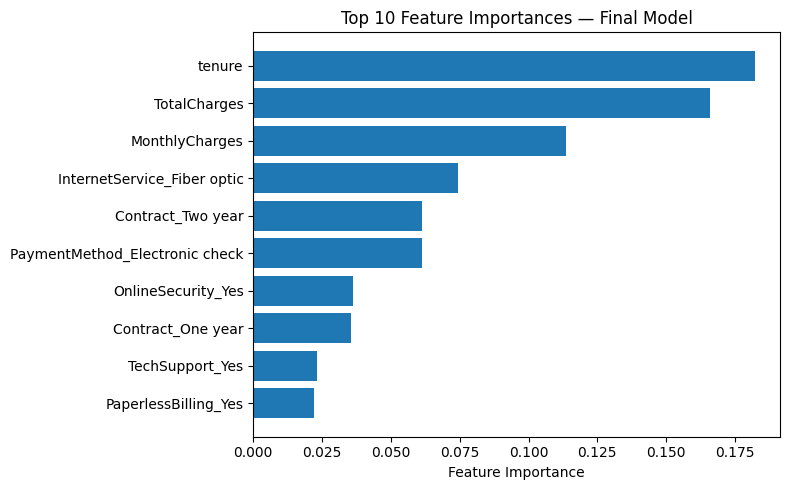

tenure                            0.182250
TotalCharges                      0.165759
MonthlyCharges                    0.113603
InternetService_Fiber optic       0.074564
Contract_Two year                 0.061463
PaymentMethod_Electronic check    0.061391
OnlineSecurity_Yes                0.036253
Contract_One year                 0.035666
TechSupport_Yes                   0.023277
PaperlessBilling_Yes              0.021926
dtype: float64

In [ ]:

final_model = tuned_rf

importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances — Final Model")
plt.tight_layout()
plt.show()

top_features

---
## Part 7  Kaggle Submission & Conclusion

### Task 16 - Build the submission-style dataframe

In [ ]:
final_test_predictions = final_model.predict(X_test)


submission = pd.DataFrame({
    "customerID": df.loc[X_test.index].index if "customerID" not in df.columns else df.loc[X_test.index, "customerID"],
    "Predicted_Churn": np.where(final_test_predictions == 1, "Yes", "No"),
})

submission.to_csv("submission.csv", index=False)
submission.head()

,customerID,Predicted_Churn
0,437,No
1,2280,Yes
2,2235,No
3,4460,No
4,3761,No




### Task 17 - Conclusion

In this lab, we compared the Decision Tree baseline from Lab 3 against a Random Forest ensemble, rigorously evaluated both using 5-fold cross-validation, and then tuned the Random Forest using GridSearchCV. We selected the tuned Random Forest as our final model, which achieved an F1-score of 0.588 and a recall of 0.527, compared to the Lab 3 Decision Tree's F1-score of 0.585 and recall of 0.545. The tuned Random Forest also had the best cross-validated F1-score (0.566) across all three models, showing that its performance is more reliable and not just the result of a lucky train/test split. Feature importance analysis showed that tenure, TotalCharges, MonthlyCharges, and having a Fiber optic internet service or a month-to-month contract were the most helpful predictors of churn. The model's remaining limitations include a recall that is still not very high, meaning a meaningful fraction of actual churners are still missed, and the underlying class imbalance (only about 26% of customers churn) has not been directly addressed, which likely caps how much further recall can improve without additional techniques.

Task 18 - What would you try next?

If given more time, I would directly address the class imbalance using techniques like SMOTE (oversampling) or class-weighting, since this could improve recall on the minority churn class. I would also compare other ensemble algorithms such as Gradient Boosting or XGBoost, and run a deeper hyperparameter search using RandomizedSearchCV with a larger grid to see whether performance improves further beyond what the current small grid search achieved.